# Speed Dating — version renforcée, détaillée et orientée business

**Objectif business :** comprendre ce qui augmente la probabilité qu'un speed date débouche sur une **décision positive** (`dec`) puis sur un **match mutuel** (`match`), afin d'aider une app type Tinder à mieux comprendre les leviers d'intérêt entre deux personnes.

## Pourquoi cette version est plus forte
Cette version va plus loin qu'une EDA classique :

1. elle **respecte l'énoncé** (statistiques descriptives + visualisations + interprétations) ;
2. elle **s'appuie sur le cours** (data manipulation, statistiques descriptives, groupby, corrélations, visualisation) ;
3. elle distingue **ce qui existe avant la rencontre** (profil, préférences, contexte) de **ce qui se joue pendant la rencontre** (attractiveness, fun, shared interests, etc.) ;
4. elle répond **point par point** aux questions suggérées dans le sujet ;
5. elle ajoute un **bonus modeling** pour comparer le pouvoir prédictif des variables.

## Résumé exécutif
Sur **8,378 lignes** (soit **4,184 speed dates uniques**, vus des deux points de vue), le taux de **match mutuel** est d'environ **16.5%**.  
Les hommes disent plus souvent “oui” (**47.4%**) que les femmes (**36.5%**), mais le **taux final de match** est quasiment identique des deux côtés (**16.5%** vs **16.5%**).  
Les signaux les plus liés au succès d'un date sont surtout **l'attractivité perçue**, le **fun**, les **intérêts partagés** et, plus globalement, le fait de **beaucoup apprécier la personne** (`like`).  
À l'inverse, les variables “profil pur” expliquent beaucoup moins le résultat final que les impressions construites pendant l'interaction.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

def find_file(candidates, required=True):
    search_roots = [
        Path.cwd(),
        Path.cwd() / "data",
        Path.cwd().parent,
        Path.cwd().parent / "data",
        Path.cwd() / "SPEED DATING PROJET_BLOC 2",
        Path.cwd().parent / "SPEED DATING PROJET_BLOC 2",
        Path("/mnt/data"),
        Path("/mnt/data/SPEED DATING PROJET_BLOC 2"),
    ]
    for root in search_roots:
        for name in candidates:
            p = root / name
            if p.exists():
                return p
    if required:
        raise FileNotFoundError(f"Impossible de trouver un fichier parmi : {candidates}")
    return None

DATA_PATH = find_file([
    "speed_dating_data.csv",
    "Speed+Dating+Data (1).csv",
    "Speed+Dating+Data.csv"
])

KEY_PATH = find_file([
    "speed_dating_data_key.doc",
    "Speed+Dating+Data+Key.doc",
    "Speed+Dating+Data+Key (1).doc"
], required=False)

print("Dataset trouvé :", DATA_PATH)
print("Data key trouvé :", KEY_PATH if KEY_PATH is not None else "non requis pour exécuter le notebook")


Dataset trouvé : /mnt/data/Speed+Dating+Data (1).csv
Data key trouvé : /mnt/data/Speed+Dating+Data+Key.doc


## 1. Chargement des données et compréhension rapide de la structure

**Point méthodologique important :**  
chaque ligne représente la **vision d'un participant sur un date donné**.  
Donc un même speed date apparaît **deux fois** dans la table :
- une fois vu par la personne A ;
- une fois vu par la personne B.

C'est très utile pour analyser les notes données pendant le date, mais il faut le garder en tête quand on parle du nombre réel de rencontres.

In [2]:
df = pd.read_csv(DATA_PATH, encoding="latin1")
print("Shape :", df.shape)
display(df.head(3))

tmp = df[['wave','iid','pid','match']].dropna(subset=['pid']).copy()
tmp['pair_id'] = tmp.apply(lambda r: f"{int(r.wave)}_{min(int(r.iid), int(r.pid))}_{max(int(r.iid), int(r.pid))}", axis=1)
pair_df = tmp.drop_duplicates('pair_id')

summary_df = pd.DataFrame({
    "metric": [
        "Rows in dataset",
        "Unique speed dates",
        "Unique participants",
        "Number of waves",
        "Row-level match rate",
        "Decision yes rate (`dec`)"
    ],
    "value": [
        len(df),
        len(pair_df),
        df['iid'].nunique(),
        df['wave'].nunique(),
        round(df['match'].mean()*100, 2),
        round(df['dec'].mean()*100, 2),
    ]
})
display(summary_df)

Shape : (8378, 195)


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,undergra,mn_sat,tuition,race,imprace,imprelig,from,zipcode,income,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,expnum,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr4_1,sinc4_1,intel4_1,fun4_1,amb4_1,shar4_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,attr1_s,sinc1_s,intel1_s,fun1_s,amb1_s,shar1_s,attr3_s,sinc3_s,intel3_s,fun3_s,amb3_s,satis_2,length,numdat_2,attr7_2,sinc7_2,intel7_2,fun7_2,amb7_2,shar7_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr4_2,sinc4_2,intel4_2,fun4_2,amb4_2,shar4_2,attr2_2,sinc2_2,intel2_2,fun2_2,amb2_2,shar2_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2,attr5_2,sinc5_2,intel5_2,fun5_2,amb5_2,you_call,them_cal,date_3,numdat_3,num_in_3,attr1_3,sinc1_3,intel1_3,fun1_3,amb1_3,shar1_3,attr7_3,sinc7_3,intel7_3,fun7_3,amb7_3,shar7_3,attr4_3,sinc4_3,intel4_3,fun4_3,amb4_3,shar4_3,attr2_3,sinc2_3,intel2_3,fun2_3,amb2_3,shar2_3,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,1,11.0,0,0.14,0,27.0,2.0,35.0,20.0,20.0,20.0,0.0,5.0,0,6.0,8.0,8.0,8.0,8.0,6.0,7.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,6.0,9.0,7.0,7.0,6.0,5.0,7.0,6.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,2,12.0,0,0.54,0,22.0,2.0,60.0,0.0,0.0,40.0,0.0,0.0,0,7.0,8.0,10.0,7.0,7.0,5.0,8.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,7.0,8.0,7.0,8.0,5.0,6.0,7.0,5.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,3,13.0,1,0.16,1,22.0,4.0,19.0,18.0,19.0,18.0,14.0,12.0,1,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,5.0,8.0,9.0,8.0,5.0,7.0,7.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


,metric,value
0,Rows in dataset,8378.00
1,Unique speed dates,4184.00
2,Unique participants,551.00
3,Number of waves,21.00
4,Row-level match rate,16.47
5,Decision yes rate (`dec`),41.99


## 1 bis. Bien choisir l'unité d'analyse

Ce dataset mélange en réalité **trois niveaux d'analyse** :

- le **niveau ligne** : la perception d'un participant sur un date précis ;
- le **niveau participant** : ses taux moyens, ses attentes, son auto-évaluation ;
- le **niveau paire** : un speed date réel entre deux personnes.

C'est un point important pour rester rigoureux :
- `dec` se lit naturellement **au niveau ligne** ;
- `match`, lui, peut aussi se lire **au niveau paire**, car un même rendez-vous apparaît deux fois dans le dataset (une fois par personne).

In [3]:
work = df.copy()
work['pair_low'] = work[['iid','pid']].min(axis=1)
work['pair_high'] = work[['iid','pid']].max(axis=1)
work['age_gap'] = (work['age'] - work['age_o']).abs()

pair_df = (
    work.groupby(['wave','pair_low','pair_high'])
        .agg(
            match=('match','first'),
            samerace=('samerace','first'),
            shar_pair=('shar','mean'),
            attr_pair=('attr','mean'),
            fun_pair=('fun','mean'),
            like_pair=('like','mean'),
            age_gap=('age_gap','mean')
        )
        .reset_index()
)

analysis_levels = pd.DataFrame({
    'Niveau': ['Ligne (perception individuelle)', 'Participant', 'Paire (date réel)'],
    'Volume': [len(df), df['iid'].nunique(), len(pair_df)],
    'Exemple de variable cible': ['dec', 'taux moyen de match', 'match'],
    'Lecture': [
        'Une personne évalue un date',
        'On résume le comportement d’un individu sur toute la soirée',
        'On observe un rendez-vous unique entre deux personnes'
    ]
})

display(analysis_levels)
print("Taux de match au niveau ligne :", f"{df['match'].mean():.2%}")
print("Taux de match au niveau paire :", f"{pair_df['match'].mean():.2%}")

,Niveau,Volume,Exemple de variable cible,Lecture
0,Ligne (perception individuelle),8378,dec,Une personne évalue un date
1,Participant,551,taux moyen de match,On résume le comportement d’un individu sur to...
2,Paire (date réel),4194,match,On observe un rendez-vous unique entre deux pe...


Taux de match au niveau ligne : 16.47%
Taux de match au niveau paire : 16.45%


**Pourquoi c'est utile ?**

- le **taux de match** est identique au niveau ligne et au niveau paire, ce qui rassure sur les KPI globaux ;
- mais pour certains checks de robustesse, travailler au **niveau paire** évite de “compter deux fois” la même rencontre ;
- on gardera donc une logique simple :
  - `dec` → plutôt **niveau ligne** ;
  - `match` → **niveau ligne** pour les KPI, et **niveau paire** pour certains approfondissements.

## 2. Qualité des données

Avant toute interprétation, on vérifie :
- les types ;
- les valeurs manquantes ;
- les doublons exacts ;
- les variables utiles pour l'analyse.

Le dataset contient beaucoup de variables issues de plusieurs questionnaires, donc il est normal d'avoir des **manquants importants** sur certaines colonnes.  
Le but ici n'est pas de remplir artificiellement toute la base, mais de travailler proprement sur les variables pertinentes pour chaque question.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


None

Nombre de doublons exacts : 0


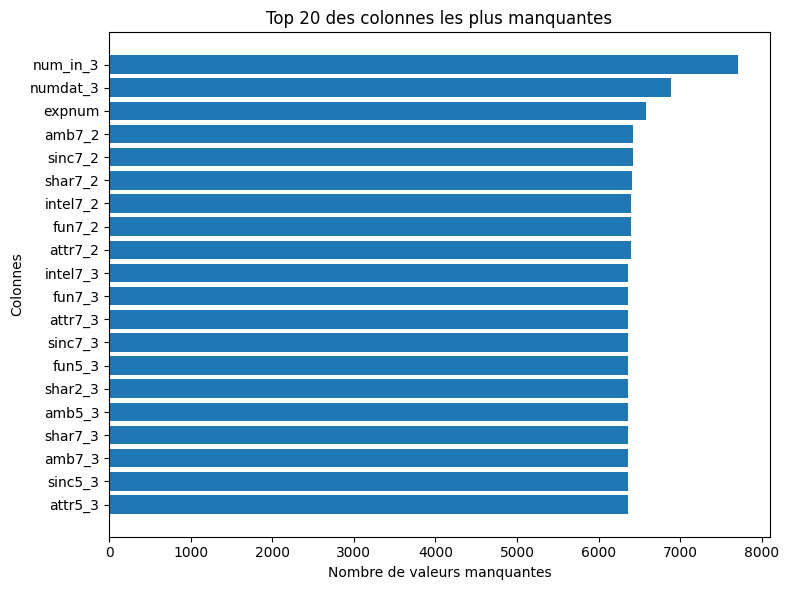

,missing_values
num_in_3,7710
numdat_3,6882
expnum,6578
sinc7_2,6423
amb7_2,6423
shar7_2,6404
attr7_2,6394
fun7_2,6394
intel7_2,6394
fun5_3,6362


In [4]:
display(df.info())

na_counts = df.isna().sum().sort_values(ascending=False)
dupes = df.duplicated().sum()
print("Nombre de doublons exacts :", dupes)

na_top20 = na_counts.head(20).sort_values(ascending=True)

plt.figure(figsize=(8,6))
plt.barh(na_top20.index, na_top20.values)
plt.title("Top 20 des colonnes les plus manquantes")
plt.xlabel("Nombre de valeurs manquantes")
plt.ylabel("Colonnes")
plt.tight_layout()
plt.show()

display(na_counts.head(20).to_frame("missing_values"))

## 3. Les cibles business : `dec` et `match`

Deux notions sont importantes :

- **`dec`** : le participant dit “oui” à une deuxième rencontre ;
- **`match`** : les **deux** participants ont dit “oui”.

Dans une logique produit :
- `dec` correspond à l'**intérêt individuel** ;
- `match` correspond au **succès final réciproque**.

C'est une distinction essentielle : quelqu'un peut plaire à une personne sans que l'intérêt soit mutuel.

,n,yes_rate,match_rate,age_mean
gender,,,,
Femmes,4184,36.54%,16.49%,26.11
Hommes,4194,47.42%,16.45%,26.61


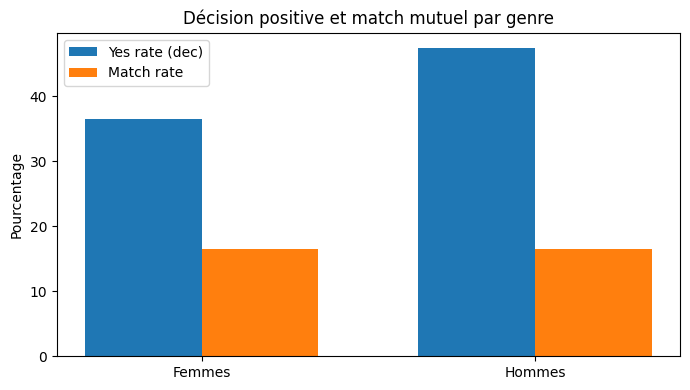

In [5]:
gender_summary = (
    df.groupby('gender')
      .agg(
          n=('match','size'),
          yes_rate=('dec','mean'),
          match_rate=('match','mean'),
          age_mean=('age','mean')
      )
      .rename(index={0:'Femmes', 1:'Hommes'})
)

display(gender_summary.style.format({
    'yes_rate': '{:.2%}',
    'match_rate': '{:.2%}',
    'age_mean': '{:.2f}'
}))

plot_df = gender_summary[['yes_rate', 'match_rate']].copy() * 100
x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, plot_df['yes_rate'], width, label='Yes rate (dec)')
plt.bar(x + width/2, plot_df['match_rate'], width, label='Match rate')
plt.xticks(x, plot_df.index)
plt.ylabel("Pourcentage")
plt.title("Décision positive et match mutuel par genre")
plt.legend()
plt.tight_layout()
plt.show()

**Lecture :**
- les **hommes disent plus souvent “oui”** (**47.4%**) que les femmes (**36.5%**) ;
- pourtant, le **taux final de match** est presque identique (**16.5%** vs **16.5%**).

Donc, dire plus souvent “oui” ne suffit pas : ce qui compte vraiment est la **réciprocité**.

## 3 ter. Check de robustesse : regarder les taux par participant

Les taux calculés ligne par ligne sont utiles, mais un participant apparaît plusieurs fois dans le dataset.  
Pour une lecture plus robuste, on calcule aussi, pour chaque personne :

- son **yes rate moyen** ;
- son **match rate moyen** ;

puis on compare ces distributions entre hommes et femmes.

,Metric,Genre,Moyenne,IC95 bas,IC95 haut,n participants
0,yes_rate,Femmes,37.38%,34.54%,40.22%,274
1,yes_rate,Hommes,48.11%,45.04%,51.18%,277
2,match_rate,Femmes,16.87%,15.09%,18.64%,274
3,match_rate,Hommes,16.92%,15.15%,18.69%,277


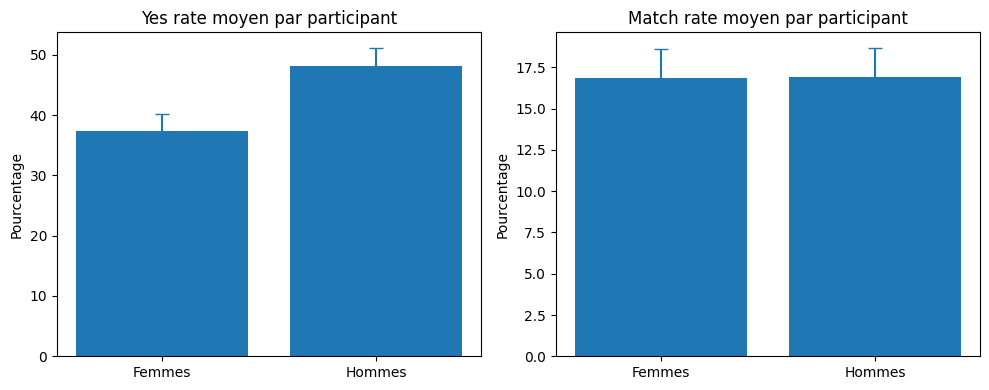

In [6]:
participant_rates = (
    df.groupby(['iid','gender'])
      .agg(
          yes_rate=('dec','mean'),
          match_rate=('match','mean'),
          n_dates=('dec','size')
      )
      .reset_index()
)

rows = []
for metric in ['yes_rate', 'match_rate']:
    for g, label in [(0, 'Femmes'), (1, 'Hommes')]:
        x = participant_rates.loc[participant_rates['gender'] == g, metric].dropna()
        mean = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x))
        ci_low = mean - 1.96 * se
        ci_high = mean + 1.96 * se
        rows.append({
            'Metric': metric,
            'Genre': label,
            'Moyenne': mean,
            'IC95 bas': ci_low,
            'IC95 haut': ci_high,
            'n participants': len(x)
        })

participant_ci = pd.DataFrame(rows)
display(participant_ci.style.format({'Moyenne':'{:.2%}','IC95 bas':'{:.2%}','IC95 haut':'{:.2%}'}))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, metric, title in zip(axes, ['yes_rate','match_rate'], ['Yes rate moyen par participant', 'Match rate moyen par participant']):
    sub = participant_ci[participant_ci['Metric'] == metric].copy()
    ax.bar(sub['Genre'], sub['Moyenne']*100)
    ax.errorbar(sub['Genre'], sub['Moyenne']*100,
                yerr=[(sub['Moyenne']-sub['IC95 bas'])*100, (sub['IC95 haut']-sub['Moyenne'])*100],
                fmt='none', capsize=5)
    ax.set_ylabel("Pourcentage")
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Ce check confirme le message principal :**
- l'écart hommes / femmes sur le **yes rate** reste bien visible même quand on raisonne **par participant** ;
- en revanche, l'écart sur le **match rate** reste faible ;
- donc le résultat n'est pas un artefact dû au fait que chaque personne apparaît plusieurs fois.

Autrement dit :  
**les hommes disent plus souvent “oui”, mais cela ne se transforme pas mécaniquement en plus de matchs.**

## 3 bis. Executive summary — les messages à retenir tout de suite

Avant de rentrer dans les détails, on peut résumer le projet en quelques messages business très clairs :

1. le **taux de match mutuel** est relativement faible, autour de **16,5%** ;
2. les **hommes disent plus souvent “oui”** que les femmes, mais cela ne se traduit **pas** par davantage de matches mutuels ;
3. au moment du date, les signaux les plus liés au **match** sont surtout **`like`**, **`fun`**, **`shared interests`** et **`attractiveness`** ;
4. les **intérêts partagés** ont un effet bien plus net que le simple fait d'être de la même race ;
5. dans une logique produit type Tinder, les variables **relationnelles** semblent donc plus utiles que les variables **démographiques brutes**.


In [7]:
top_corr = (
    df[['match','attr','fun','shar','like']]
      .corr(numeric_only=True)['match']
      .drop('match')
      .sort_values(ascending=False)
)

kpis = pd.DataFrame({
    'KPI': [
        'Taux de yes individuel',
        'Taux de match mutuel',
        'Yes rate hommes',
        'Yes rate femmes',
        'Match rate hommes',
        'Match rate femmes'
    ],
    'Valeur': [
        df['dec'].mean(),
        df['match'].mean(),
        df.loc[df['gender']==1, 'dec'].mean(),
        df.loc[df['gender']==0, 'dec'].mean(),
        df.loc[df['gender']==1, 'match'].mean(),
        df.loc[df['gender']==0, 'match'].mean(),
    ]
})

display(kpis.style.format({'Valeur':'{:.2%}'}))
display(top_corr.rename('Corrélation avec match').to_frame().style.format('{:.3f}'))


,KPI,Valeur
0,Taux de yes individuel,41.99%
1,Taux de match mutuel,16.47%
2,Yes rate hommes,47.42%
3,Yes rate femmes,36.54%
4,Match rate hommes,16.45%
5,Match rate femmes,16.49%


,Corrélation avec match
like,0.306
fun,0.278
shar,0.271
attr,0.261


## 4. Qu'est-ce qui est le plus lié à une issue positive ?

On commence par les notes attribuées pendant le date :
- `attr` : attractiveness
- `sinc` : sincerity
- `intel` : intelligence
- `fun` : fun
- `amb` : ambition
- `shar` : shared interests
- `like` : à quel point j'apprécie la personne
- `prob` : probabilité perçue que l'autre dise oui

Ces variables sont très informatives, mais attention : certaines sont presque contemporaines de la décision (`like`, `prob`).  
Elles sont donc excellentes pour **décrire** ce qui se passe pendant le date, mais moins utiles comme leviers “profil avant rencontre”.

match,No match,Match
attr,5.961230,7.319535
sinc,7.046056,7.809489
intel,7.249851,7.950365
fun,6.155185,7.598535
amb,6.663891,7.332949
shar,5.208230,6.753571
like,5.880169,7.381904
prob,4.961883,6.412884


,corr_with_dec,corr_with_match
like,0.513463,0.305723
fun,0.414477,0.277545
shar,0.400644,0.270679
attr,0.486775,0.260676
prob,0.310861,0.255531
intel,0.217313,0.169532
sinc,0.209994,0.164449
amb,0.183659,0.140042


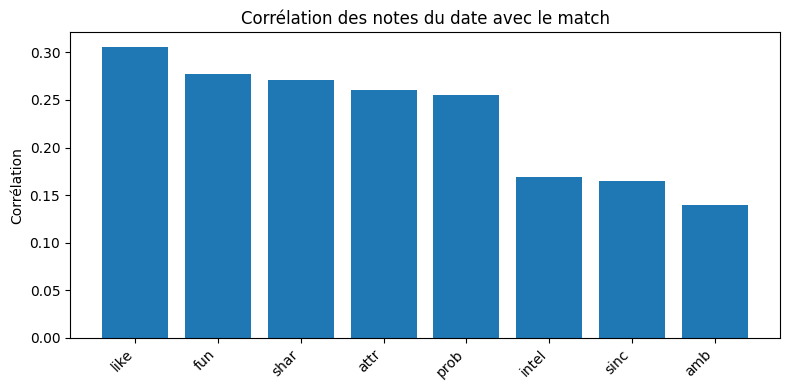

In [8]:
rating_cols = ['attr','sinc','intel','fun','amb','shar','like','prob']

mean_by_match = df.groupby('match')[rating_cols].mean().T.rename(columns={0:'No match', 1:'Match'})
corr_match = df[rating_cols + ['match']].corr(numeric_only=True)['match'].drop('match').sort_values(ascending=False)
corr_dec = df[rating_cols + ['dec']].corr(numeric_only=True)['dec'].drop('dec').sort_values(ascending=False)

display(mean_by_match)
display(pd.DataFrame({
    'corr_with_dec': corr_dec,
    'corr_with_match': corr_match
}).sort_values('corr_with_match', ascending=False))

plt.figure(figsize=(8,4))
plt.bar(corr_match.index, corr_match.values)
plt.title("Corrélation des notes du date avec le match")
plt.ylabel("Corrélation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Ce qu'on voit très clairement :**
- `like` est le signal le plus lié au match ;
- parmi les six attributs “classiques”, les plus forts sont surtout **`fun`**, **`shar`** et **`attr`** ;
- `amb` et `sinc` comptent, mais moins.

Autrement dit : les dates qui marchent sont surtout ceux où la personne est perçue comme **agréable, attirante et compatible en centres d'intérêt**.

## 5. Question du sujet : quelles qualités sont les moins désirables ? Est-ce différent selon le genre ?

Le sujet propose de comparer ce que les gens déclarent rechercher chez un partenaire.

### Point méthodologique important
Les vagues 6 à 9 utilisent une échelle **1–10**, alors que beaucoup d'autres vagues utilisent une **allocation de 100 points**.  
Pour rendre les comparaisons propres, on convertit les réponses en **poids relatifs (%) au sein de chaque répondant**.

Ainsi :
- on respecte la structure du questionnaire ;
- on évite de mélanger directement des échelles brutes différentes.

gender,Femmes évaluant des hommes,Hommes évaluant des femmes
Attractiveness,18.06%,26.91%
Sincerity,18.31%,16.48%
Intelligence,21.01%,19.52%
Fun,17.15%,17.75%
Ambition,12.83%,8.50%
Shared interests,12.71%,10.97%


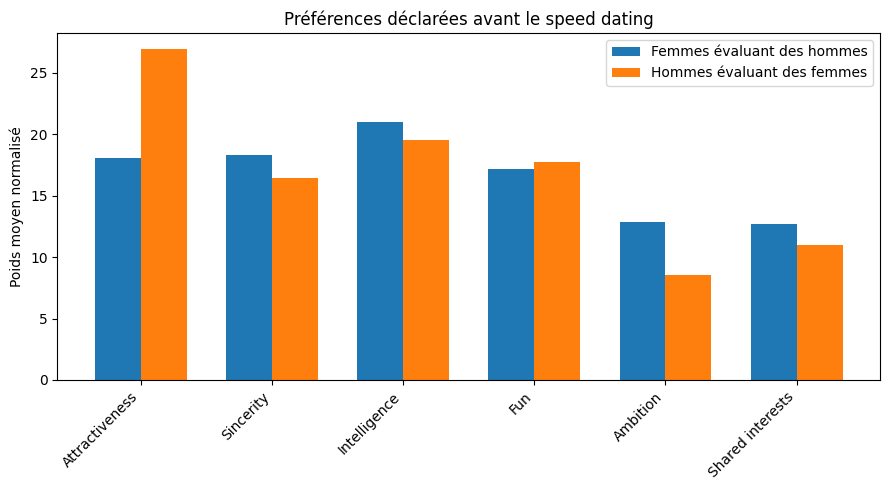

In [9]:
pref_cols = ['attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1','shar1_1']
pref_labels = {
    'attr1_1':'Attractiveness',
    'sinc1_1':'Sincerity',
    'intel1_1':'Intelligence',
    'fun1_1':'Fun',
    'amb1_1':'Ambition',
    'shar1_1':'Shared interests'
}

pref_work = df[['gender'] + pref_cols].copy()
pref_sum = pref_work[pref_cols].sum(axis=1)
for c in pref_cols:
    pref_work[c + '_share'] = np.where(pref_sum > 0, pref_work[c] / pref_sum * 100, np.nan)

pref_share_gender = (
    pref_work.groupby('gender')[[c + '_share' for c in pref_cols]]
             .mean()
             .rename(index={0:'Femmes évaluant des hommes', 1:'Hommes évaluant des femmes'})
             .T
)
pref_share_gender.index = [pref_labels[c.replace('_share', '')] for c in pref_share_gender.index]

display(pref_share_gender.style.format('{:.2f}%'))

plot_df = pref_share_gender.copy()
x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, plot_df.iloc[:,0], width, label=plot_df.columns[0])
plt.bar(x + width/2, plot_df.iloc[:,1], width, label=plot_df.columns[1])
plt.xticks(x, plot_df.index, rotation=45, ha='right')
plt.ylabel("Poids moyen normalisé")
plt.title("Préférences déclarées avant le speed dating")
plt.legend()
plt.tight_layout()
plt.show()

**Résultat :**
- chez les **hommes évaluant des femmes**, la qualité la moins valorisée est surtout **l'ambition** (~**8.5%**), puis les **intérêts partagés** (~**11.0%**) ;
- chez les **femmes évaluant des hommes**, les deux plus faibles poids sont **les intérêts partagés** et **l'ambition**, très proches (~**12.7%** et **12.8%**).

Donc oui, il y a des différences de hiérarchie, mais dans les deux cas **l'ambition est en bas du classement**.

## 6. Attractiveness : importance déclarée vs impact réel

C'est une des meilleures questions du sujet.

On la traite en trois angles :
1. **avant l'événement** : ce que les participants disent rechercher ;
2. **après l'événement** : ce qu'ils disent avoir réellement utilisé ;
3. **dans les faits** : ce qui est le plus lié à la décision `dec`.

Cela permet de comparer les **discours** et les **comportements observés**.

gender,Femmes,Hommes
Attractiveness,29.15%,37.41%
Sincerity,15.37%,11.71%
Intelligence,15.54%,14.99%
Fun,18.40%,19.39%
Ambition,8.19%,6.39%
Shared interests,13.79%,10.40%


gender,Femmes,Hommes
Attractiveness,0.445,0.515
Sincerity,0.222,0.191
Intelligence,0.233,0.217
Fun,0.417,0.407
Ambition,0.175,0.220
Shared interests,0.413,0.387


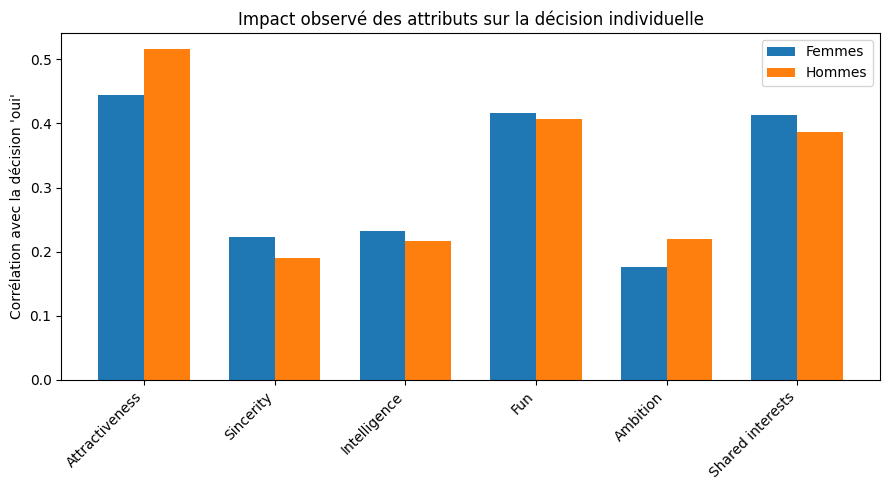

In [10]:
post_cols = ['attr7_2','sinc7_2','intel7_2','fun7_2','amb7_2','shar7_2']
post_labels = {
    'attr7_2':'Attractiveness',
    'sinc7_2':'Sincerity',
    'intel7_2':'Intelligence',
    'fun7_2':'Fun',
    'amb7_2':'Ambition',
    'shar7_2':'Shared interests'
}

post_work = df[['gender'] + post_cols].copy()
post_sum = post_work[post_cols].sum(axis=1)
for c in post_cols:
    post_work[c + '_share'] = np.where(post_sum > 0, post_work[c] / post_sum * 100, np.nan)

post_share_gender = (
    post_work.groupby('gender')[[c + '_share' for c in post_cols]]
             .mean()
             .rename(index={0:'Femmes', 1:'Hommes'})
             .T
)
post_share_gender.index = [post_labels[c.replace('_share', '')] for c in post_share_gender.index]

obs_rows = []
for g in [0, 1]:
    sub = df[df['gender'] == g]
    for feat in ['attr','sinc','intel','fun','amb','shar']:
        temp = sub[[feat, 'dec']].dropna()
        obs_rows.append({
            'gender': 'Femmes' if g == 0 else 'Hommes',
            'feature': feat,
            'corr_with_dec': temp[feat].corr(temp['dec'])
        })

obs_impact = pd.DataFrame(obs_rows)
obs_pivot = obs_impact.pivot(index='feature', columns='gender', values='corr_with_dec').loc[['attr','sinc','intel','fun','amb','shar']]
obs_pivot.index = ['Attractiveness','Sincerity','Intelligence','Fun','Ambition','Shared interests']

display(post_share_gender.style.format('{:.2f}%'))
display(obs_pivot.style.format('{:.3f}'))

plot_df = obs_pivot.copy()
x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, plot_df['Femmes'], width, label='Femmes')
plt.bar(x + width/2, plot_df['Hommes'], width, label='Hommes')
plt.xticks(x, plot_df.index, rotation=45, ha='right')
plt.ylabel("Corrélation avec la décision 'oui'")
plt.title("Impact observé des attributs sur la décision individuelle")
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion forte :**
- l'**attractiveness** est déjà importante dans les préférences déclarées ;
- après l'événement, elle devient encore plus centrale dans le récit des participants ;
- et dans les données observées, elle est bien l'un des plus gros leviers de décision, surtout chez les hommes.

Mais le point vraiment intéressant est le suivant :  
**l'attractiveness n'agit pas seule**. Les variables **`fun`** et **`shared interests`** rivalisent fortement avec elle.  
Donc un bon projet ne doit pas raconter : *“tout est une question de physique”*.  
Le bon message est : **le physique compte beaucoup, mais l'alchimie et la compatibilité comptent aussi énormément.**

## 7. Shared interests vs same race

Autre question très directement suggérée par le sujet :  
les intérêts partagés sont-ils plus importants qu'un même background racial ?

On compare ici deux types de signaux :

- `samerace` : proximité démographique simple (0/1) ;
- `shar` : perception directe d'intérêts / hobbies partagés pendant la rencontre.

C'est une comparaison très importante pour Tinder, car elle oppose :
- un critère **statique** ;
- à un critère **relationnel** beaucoup plus proche de la compatibilité vécue.


,yes_rate,match_rate,n
samerace,,,
Race différente,41.07%,16.08%,5062
Même race,43.40%,17.07%,3316


,yes_rate,match_rate,n
shar_bin,,,
"(-0.001, 3.0]",13.71%,4.89%,1371
"(3.0, 5.0]",33.67%,9.83%,2248
"(5.0, 7.0]",54.06%,22.07%,2401
"(7.0, 10.0]",71.57%,34.24%,1291


,Signal,Match rate bas / ref,Match rate haut / exposé,Lift relatif
0,Même race,16.08%,17.07%,+6.1%
1,Shared interests : très haut vs très bas,4.89%,34.24%,+600.6%


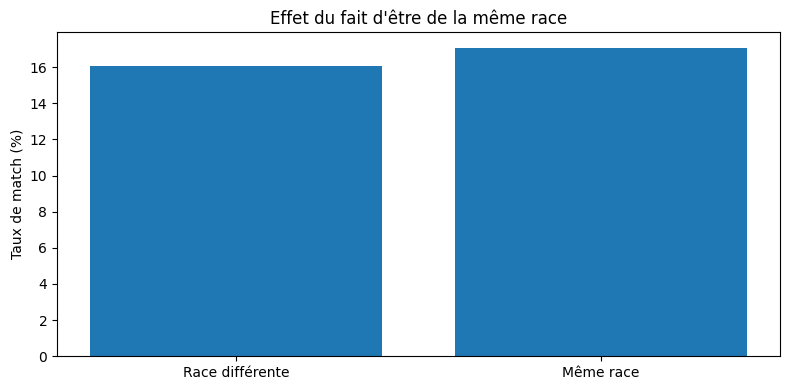

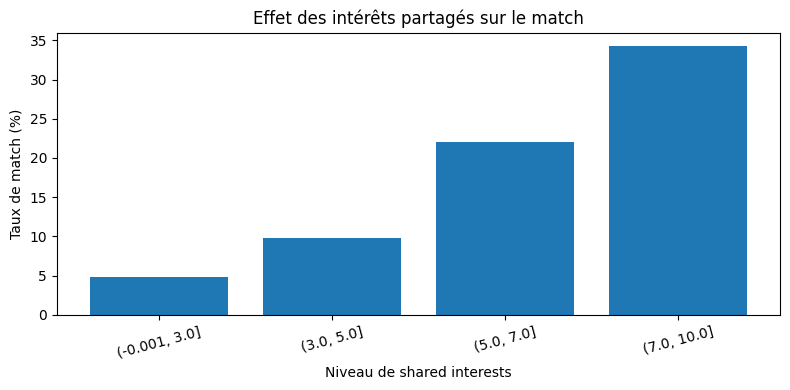

In [11]:
same_race_summary = (
    df.groupby('samerace')
      .agg(
          yes_rate=('dec','mean'),
          match_rate=('match','mean'),
          n=('match','size')
      )
      .rename(index={0:'Race différente', 1:'Même race'})
)

shar_tmp = df[['shar','dec','match']].dropna().copy()
shar_tmp['shar_bin'] = pd.cut(shar_tmp['shar'], bins=[0,3,5,7,10], include_lowest=True)
shar_summary = shar_tmp.groupby('shar_bin', observed=False).agg(
    yes_rate=('dec','mean'),
    match_rate=('match','mean'),
    n=('match','size')
)

race_lift = (
    same_race_summary.loc['Même race', 'match_rate'] / same_race_summary.loc['Race différente', 'match_rate'] - 1
)

shar_lift = (
    shar_summary['match_rate'].iloc[-1] / shar_summary['match_rate'].iloc[0] - 1
)

effect_comparison = pd.DataFrame({
    'Signal': ['Même race', 'Shared interests : très haut vs très bas'],
    'Match rate bas / ref': [
        same_race_summary.loc['Race différente', 'match_rate'],
        shar_summary['match_rate'].iloc[0]
    ],
    'Match rate haut / exposé': [
        same_race_summary.loc['Même race', 'match_rate'],
        shar_summary['match_rate'].iloc[-1]
    ],
    'Lift relatif': [race_lift, shar_lift]
})

display(same_race_summary.style.format({'yes_rate':'{:.2%}','match_rate':'{:.2%}'}))
display(shar_summary.style.format({'yes_rate':'{:.2%}','match_rate':'{:.2%}'}))
display(effect_comparison.style.format({
    'Match rate bas / ref':'{:.2%}',
    'Match rate haut / exposé':'{:.2%}',
    'Lift relatif':'{:+.1%}'
}))

plt.figure(figsize=(8,4))
plt.bar(['Race différente', 'Même race'], same_race_summary['match_rate']*100)
plt.ylabel("Taux de match (%)")
plt.title("Effet du fait d'être de la même race")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(shar_summary.index.astype(str), shar_summary['match_rate']*100)
plt.ylabel("Taux de match (%)")
plt.xlabel("Niveau de shared interests")
plt.title("Effet des intérêts partagés sur le match")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Verdict renforcé :**
- être de la **même race** fait un peu monter le taux de match (**16.1%** → **17.1%**), soit un effet **faible** ;
- en revanche, quand `shar` passe d'un niveau très bas à un niveau élevé, le taux de match explose (**4.9%** → **34.2%**), soit un effet **beaucoup plus fort** ;
- autrement dit, le **lift relatif** lié aux intérêts partagés est sans commune mesure avec celui de `samerace`.

C'est un résultat très utile pour Tinder :  
les **centres d'intérêt partagés** sont un levier bien plus actionnable et bien plus fort que les variables démographiques brutes.


## 7 bis. Robustesse au niveau paire : compatibilité vécue vs similarité démographique

Pour aller un cran plus loin tout en restant dans l'esprit EDA, on regarde maintenant le `match`
**au niveau paire**.

Deux questions simples :

1. quand on maintient à peu près constant le niveau de `shared interests`, l'effet de `samerace` reste-t-il fort ?
2. comment évolue le taux de match quand on combine **attractiveness moyenne du duo** et **shared interests moyens** ?

,shar_band,samerace,match_rate,n
0,Très bas,0,2.72%,331
1,Très bas,1,4.76%,147
2,Bas-moyen,0,6.65%,842
3,Bas-moyen,1,7.02%,541
4,Moyen-haut,0,21.52%,948
5,Moyen-haut,1,19.47%,647
6,Très haut,0,40.36%,337
7,Très haut,1,39.34%,272


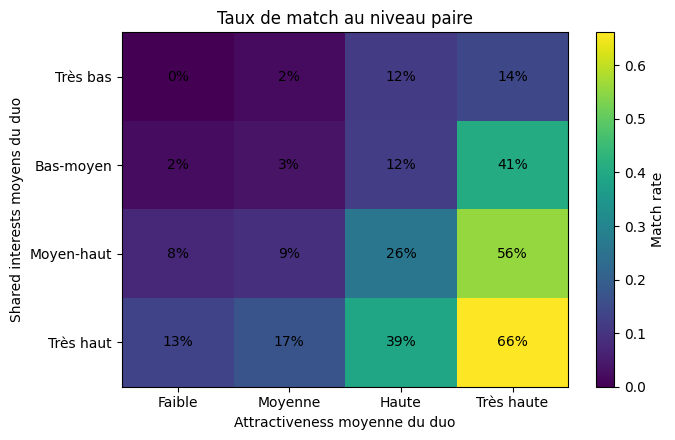

In [12]:
pair_interest = pair_df[['match','samerace','shar_pair','attr_pair']].dropna().copy()

pair_interest['shar_band'] = pd.cut(
    pair_interest['shar_pair'],
    bins=[0,3,5,7,10],
    include_lowest=True,
    labels=['Très bas', 'Bas-moyen', 'Moyen-haut', 'Très haut']
)

pair_interest['attr_band'] = pd.cut(
    pair_interest['attr_pair'],
    bins=[0,4,6,8,10],
    include_lowest=True,
    labels=['Faible', 'Moyenne', 'Haute', 'Très haute']
)

race_within_shar = (
    pair_interest.groupby(['shar_band','samerace'], observed=False)
                 .agg(match_rate=('match','mean'), n=('match','size'))
                 .reset_index()
)
display(race_within_shar.style.format({'match_rate':'{:.2%}'}))

heat = pair_interest.pivot_table(
    index='shar_band',
    columns='attr_band',
    values='match',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(7,4.5))
im = ax.imshow(heat.values, aspect='auto')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("Attractiveness moyenne du duo")
ax.set_ylabel("Shared interests moyens du duo")
ax.set_title("Taux de match au niveau paire")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.0%}", ha='center', va='center')
plt.colorbar(im, ax=ax, label='Match rate')
plt.tight_layout()
plt.show()

**Lecture robuste :**
- à niveau de `shared interests` comparable, l'effet de `samerace` reste **petit et peu stable** ;
- en revanche, quand **l'attractiveness moyenne** et les **intérêts partagés moyens** montent ensemble, le taux de match grimpe nettement ;
- cela suggère qu'une logique de **compatibilité vécue** explique mieux le résultat final qu'une simple proximité démographique.

Ce point est très bien aligné avec le sujet : on reste sur de la **statistique descriptive + visualisation**, mais avec un raisonnement plus propre.

## 8. Les participants se connaissent-ils bien eux-mêmes sur le “dating market” ?

Le sujet demande aussi :  
**les gens savent-ils estimer leur propre valeur perçue ?**

On utilise deux angles :
1. la capacité à estimer le **nombre de matches** qu'ils vont obtenir ;
2. la capacité à s'auto-évaluer sur certaines qualités, puis comparer cela aux notes réellement reçues.

,metric,value
0,"Corr(expected_matches, actual_matches)",0.429
1,"Corr(self_attr, received_attr)",0.289
2,"Corr(self_fun, received_fun)",0.280
3,"Corr(self_intel, received_intel)",0.052
4,"Corr(self_sinc, received_sinc)",-0.011
5,"Corr(self_amb, received_amb)",0.158


,expected_matches,actual_matches,match_error
gender,,,
Femmes,2.88,2.52,0.44
Hommes,3.17,2.49,0.83


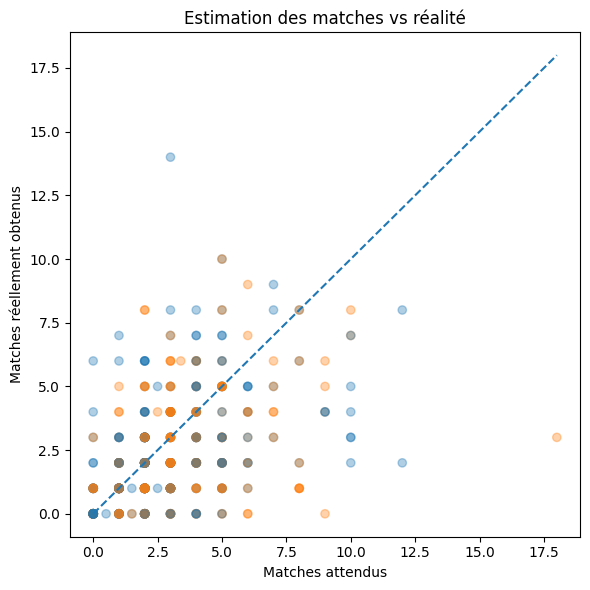

In [13]:
person = (
    df.groupby('iid')
      .agg(
          gender=('gender','first'),
          dates=('dec','size'),
          expected_yes=('expnum','first'),
          expected_matches=('match_es','first'),
          actual_yes_received=('dec_o','sum'),
          actual_matches=('match','sum'),
          self_attr=('attr3_1','first'),
          self_sinc=('sinc3_1','first'),
          self_intel=('intel3_1','first'),
          self_fun=('fun3_1','first'),
          self_amb=('amb3_1','first'),
          received_attr=('attr_o','mean'),
          received_sinc=('sinc_o','mean'),
          received_intel=('intel_o','mean'),
          received_fun=('fun_o','mean'),
          received_amb=('amb_o','mean'),
      )
      .reset_index()
)

corr_match_est = person[['expected_matches','actual_matches']].dropna().corr().iloc[0,1]

self_vs_received = {}
for feat in ['attr','sinc','intel','fun','amb']:
    temp = person[[f'self_{feat}', f'received_{feat}']].dropna()
    self_vs_received[feat] = temp.corr().iloc[0,1]

person['match_error'] = person['expected_matches'] - person['actual_matches']
bias_by_gender = (
    person.groupby('gender')[['expected_matches','actual_matches','match_error']]
          .mean()
          .rename(index={0:'Femmes', 1:'Hommes'})
)

display(pd.DataFrame({
    'metric': [
        'Corr(expected_matches, actual_matches)',
        'Corr(self_attr, received_attr)',
        'Corr(self_fun, received_fun)',
        'Corr(self_intel, received_intel)',
        'Corr(self_sinc, received_sinc)',
        'Corr(self_amb, received_amb)',
    ],
    'value': [
        corr_match_est,
        self_vs_received['attr'],
        self_vs_received['fun'],
        self_vs_received['intel'],
        self_vs_received['sinc'],
        self_vs_received['amb'],
    ]
}).style.format({'value':'{:.3f}'}))

display(bias_by_gender.style.format('{:.2f}'))

plot_people = person[['expected_matches','actual_matches','gender']].dropna()
colors = plot_people['gender'].map({0:'tab:blue', 1:'tab:orange'})

plt.figure(figsize=(6,6))
plt.scatter(plot_people['expected_matches'], plot_people['actual_matches'], alpha=0.35, c=colors)
maxv = max(plot_people['expected_matches'].max(), plot_people['actual_matches'].max())
plt.plot([0, maxv], [0, maxv], linestyle='--')
plt.xlabel("Matches attendus")
plt.ylabel("Matches réellement obtenus")
plt.title("Estimation des matches vs réalité")
plt.tight_layout()
plt.show()


**Interprétation enrichie :**
- la corrélation entre **matches estimés** et **matches réels** est **modérée** (~**0.43**) ;
- la corrélation entre **auto-évaluation de l'attractiveness** et **note réellement reçue** est seulement **faible à modérée** (~**0.29**) ;
- même chose pour le fun (~**0.28**), et c'est encore plus faible sur d'autres dimensions ;
- au niveau agrégé, les participants ont tendance à être **sur-confiants** : ils anticipent plus de matches qu'ils n'en obtiennent réellement ;
- cette **sur-estimation** existe chez les deux genres, mais elle est **plus forte chez les hommes** dans ce dataset.

Donc les participants ne sont **ni totalement lucides, ni totalement perdus** :  
ils ont une intuition partielle, mais loin d'être parfaite.


## 8 bis. Calibration : les participants sont-ils surtout lucides, ou surtout trop confiants ?

La corrélation donne un premier signal, mais on peut aller un peu plus loin avec une logique de **calibration** :

- si quelqu'un s'attend à beaucoup de matches, obtient-il réellement beaucoup de matches ?
- la sur-estimation est-elle faible ou importante ?
- diffère-t-elle selon le genre ?

Pour comparer proprement des personnes qui n'ont pas toutes rencontré exactement le même nombre de partenaires,
on raisonne en **taux attendu** et **taux réel**.

,expected_rate,actual_rate,bias,mae,n
gender,,,,,
Femmes,20.03%,16.49%,3.54%,11.64%,240
Hommes,23.18%,16.02%,7.15%,12.84%,239


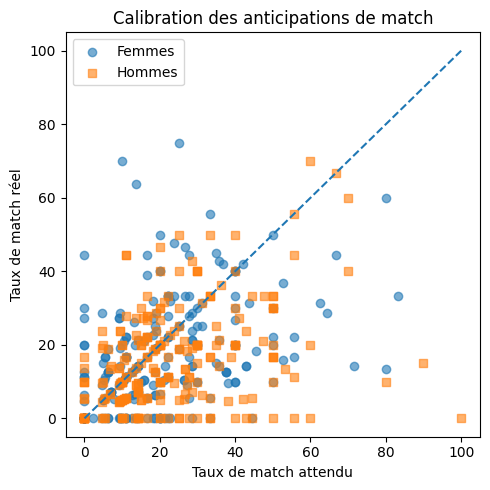

In [14]:
calib = person[['gender','dates','expected_matches','actual_matches']].dropna().copy()
calib = calib[calib['dates'] > 0]

calib['expected_rate'] = calib['expected_matches'] / calib['dates']
calib['actual_rate'] = calib['actual_matches'] / calib['dates']
calib['bias'] = calib['expected_rate'] - calib['actual_rate']
calib['abs_error'] = (calib['bias']).abs()

calib_summary = (
    calib.groupby('gender')
         .agg(
             expected_rate=('expected_rate','mean'),
             actual_rate=('actual_rate','mean'),
             bias=('bias','mean'),
             mae=('abs_error','mean'),
             n=('bias','size')
         )
         .rename(index={0:'Femmes', 1:'Hommes'})
)
display(calib_summary.style.format({'expected_rate':'{:.2%}','actual_rate':'{:.2%}','bias':'{:.2%}','mae':'{:.2%}'}))

plt.figure(figsize=(5,5))
for g, label, marker in [(0, 'Femmes', 'o'), (1, 'Hommes', 's')]:
    sub = calib[calib['gender'] == g]
    plt.scatter(sub['expected_rate']*100, sub['actual_rate']*100, alpha=0.6, label=label, marker=marker)
lim = max(calib['expected_rate'].max(), calib['actual_rate'].max()) * 100
plt.plot([0, lim], [0, lim], linestyle='--')
plt.xlabel("Taux de match attendu")
plt.ylabel("Taux de match réel")
plt.title("Calibration des anticipations de match")
plt.legend()
plt.tight_layout()
plt.show()

**Ce qu'ajoute cette lecture :**
- la plupart des points sont **sous la diagonale**, donc les participants ont tendance à **surestimer** leur succès ;
- la sur-estimation moyenne existe chez les deux genres ;
- l'erreur absolue reste non négligeable, ce qui confirme que les individus ont une lecture **imparfaite** de leur valeur perçue sur le marché du dating.

Donc la réponse au sujet est nuancée :  
**les participants ont une intuition partielle, mais ils sont loin d'être parfaitement calibrés.**

## 9. Être premier ou dernier dans la soirée : est-ce que ça change quelque chose ?

Dernière question suggérée par le sujet :  
vaut-il mieux être vu tôt ou tard dans la soirée ?

On regarde `order`, c'est-à-dire la position du date dans la séquence de la soirée.

### Point méthodologique important
Toutes les soirées n'ont pas exactement le même nombre de rounds.  
Pour éviter de comparer de manière brute un `order=5` dans une petite soirée avec un `order=5` dans une grande soirée, on travaille aussi avec un **ordre relatif dans la soirée** :

- début ;
- milieu ;
- fin.


,yes_rate,match_rate,n
order_bin,,,
Début,42.57%,17.22%,2765
Milieu,43.05%,16.67%,2639
Fin,40.52%,15.60%,2974


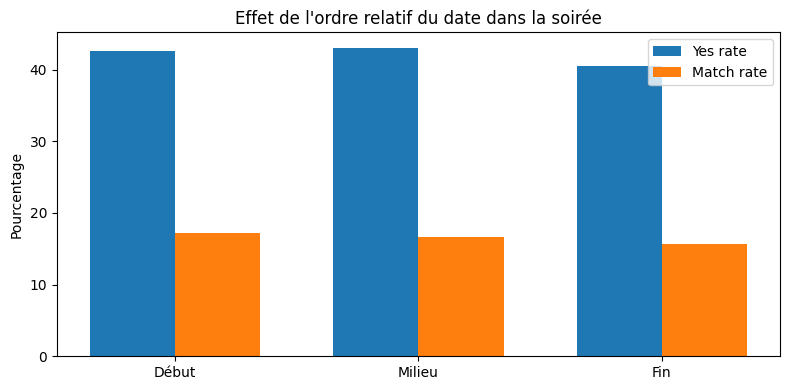

Corr(order, dec)   = -0.032
Corr(order, match) = -0.039
Corr(relative_order, match) = -0.02


In [15]:
order_tmp = df[['order','round','dec','match']].dropna().copy()
order_tmp = order_tmp[order_tmp['round'] > 1]

order_tmp['relative_order'] = (order_tmp['order'] - 1) / (order_tmp['round'] - 1)
order_tmp['order_bin'] = pd.cut(
    order_tmp['relative_order'],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=['Début', 'Milieu', 'Fin']
)

order_summary = order_tmp.groupby('order_bin', observed=False).agg(
    yes_rate=('dec','mean'),
    match_rate=('match','mean'),
    n=('match','size')
)

display(order_summary.style.format({'yes_rate':'{:.2%}', 'match_rate':'{:.2%}'}))

x = np.arange(len(order_summary.index))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, order_summary['yes_rate']*100, width, label='Yes rate')
plt.bar(x + width/2, order_summary['match_rate']*100, width, label='Match rate')
plt.xticks(x, order_summary.index)
plt.ylabel("Pourcentage")
plt.title("Effet de l'ordre relatif du date dans la soirée")
plt.legend()
plt.tight_layout()
plt.show()

print("Corr(order, dec)   =", round(order_tmp['order'].corr(order_tmp['dec']), 3))
print("Corr(order, match) =", round(order_tmp['order'].corr(order_tmp['match']), 3))
print("Corr(relative_order, match) =", round(order_tmp['relative_order'].corr(order_tmp['match']), 3))


L'effet existe, mais il reste **faible à modéré** :
- les dates du **début de soirée** ont un yes rate d'environ **42.6%**, contre **40.5%** en fin de soirée ;
- pour le match, on passe d'environ **17.2%** au début à **15.6%** à la fin ;
- le signal est donc cohérent avec une légère **fatigue / saturation**, mais cela ne fait pas partie des leviers dominants.

C'est un bon exemple de variable **contextuelle réelle**, mais secondaire par rapport à `like`, `fun`, `attr` ou `shar`.


## 10. Bonus utile : quelques variables de contexte avant la rencontre

Pour enrichir l'analyse, on peut regarder deux éléments simples et actionnables :
- l'**écart d'âge** ;
- les variables de contexte / profil pur.

L'idée est de voir ce que le produit peut utiliser **avant même que les deux personnes se parlent**.

,yes_rate,match_rate,n
gap_bin,,,
0-1,44.29%,18.87%,2226
2-3,43.02%,17.79%,2406
4-5,41.49%,15.62%,1728
6+,38.50%,12.50%,1808


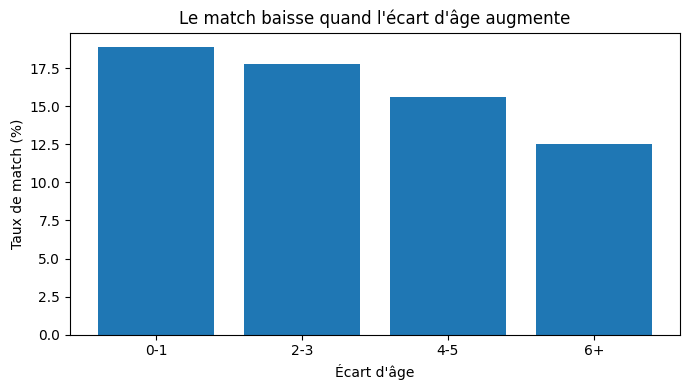

In [16]:
df['age_gap'] = (df['age'] - df['age_o']).abs()
agegap = df[['age_gap','dec','match']].dropna().copy()
agegap['gap_bin'] = pd.cut(agegap['age_gap'], bins=[-0.1,1,3,5,20], labels=['0-1','2-3','4-5','6+'])

agegap_summary = agegap.groupby('gap_bin', observed=False).agg(
    yes_rate=('dec','mean'),
    match_rate=('match','mean'),
    n=('match','size')
)

display(agegap_summary.style.format({'yes_rate':'{:.2%}', 'match_rate':'{:.2%}'}))

plt.figure(figsize=(7,4))
plt.bar(agegap_summary.index.astype(str), agegap_summary['match_rate']*100)
plt.ylabel("Taux de match (%)")
plt.xlabel("Écart d'âge")
plt.title("Le match baisse quand l'écart d'âge augmente")
plt.tight_layout()
plt.show()

L'écart d'âge n'est pas le levier principal, mais on observe tout de même une tendance :  
les petits écarts d'âge obtiennent un peu plus de matches que les écarts très élevés.

## 11. Bonus modeling : profil seul vs impressions du date

Même si le sujet n'exige pas de machine learning, ce bonus est très utile pour le storytelling final.  
Il permet de montrer **ce qui explique vraiment le résultat** :

- **modèle A : profil / contexte avant rencontre seulement**
- **modèle B : notes du date seulement**
- **modèle C : combinaison des deux**

### Upgrade méthodologique
Pour éviter une évaluation trop optimiste, on ne fait pas seulement un split aléatoire par lignes.  
On effectue ici plusieurs **hold-out par participant (`iid`)**, afin que les mêmes personnes ne soient pas à la fois dans l'entraînement et dans le test.

On utilise ici une **régression logistique** simple avec :
- imputation médiane ;
- standardisation ;
- `class_weight='balanced'` car les matches sont minoritaires.


,model,roc_auc_mean,roc_auc_std,accuracy_mean,f1_mean
1,Impressions du date,0.776,0.009,0.694,0.438
2,Profil + date,0.774,0.006,0.706,0.441
0,Profil / contexte,0.565,0.008,0.564,0.277


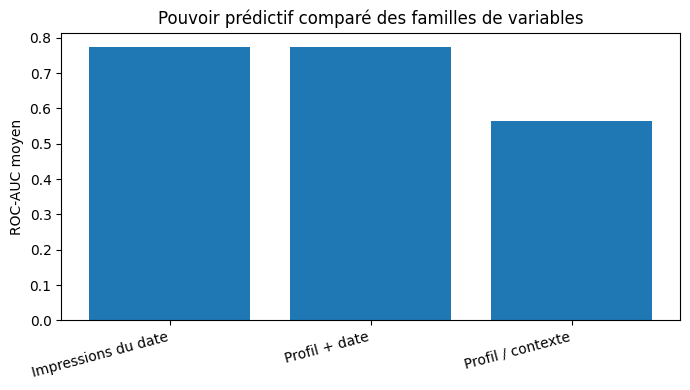

,feature,importance
35,like,0.0471
29,attr,0.0294
36,prob,0.0273
32,fun,0.0238
34,shar,0.0082
33,amb,0.0072
20,clubbing,0.0054
31,intel,0.0041
17,art,0.0040
16,museums,0.0028


In [17]:
def evaluate_logreg_grouped(data, target, features, group_col='iid', n_splits=5, random_state=42):
    work = data[features + [target, group_col]].copy()
    X = work[features]
    y = work[target].astype(int)
    groups = work[group_col]

    splitter = GroupShuffleSplit(n_splits=n_splits, test_size=0.25, random_state=random_state)

    fold_rows = []
    fitted_pipe = None
    X_test_last = None
    y_test_last = None

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
        ])

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        proba = pipe.predict_proba(X_test)[:, 1]

        fold_rows.append({
            'fold': fold,
            'roc_auc': roc_auc_score(y_test, proba),
            'accuracy': accuracy_score(y_test, pred),
            'f1': f1_score(y_test, pred),
        })

        fitted_pipe = pipe
        X_test_last = X_test
        y_test_last = y_test

    return pd.DataFrame(fold_rows), fitted_pipe, X_test_last, y_test_last

profile_features = [c for c in [
    'gender','age','age_o','samerace','order','int_corr','imprace','imprelig',
    'date','go_out','exphappy','expnum',
    'sports','tvsports','exercise','dining','museums','art','hiking',
    'gaming','clubbing','reading','tv','theater','movies','concerts',
    'music','shopping','yoga'
] if c in df.columns]

date_features = [c for c in ['attr','sinc','intel','fun','amb','shar','like','prob'] if c in df.columns]
combined_features = profile_features + date_features

cv_profile, _, _, _ = evaluate_logreg_grouped(df, 'match', profile_features)
cv_date, _, _, _ = evaluate_logreg_grouped(df, 'match', date_features)
cv_combined, fitted_combined, X_test_last, y_test_last = evaluate_logreg_grouped(df, 'match', combined_features)

model_results = pd.DataFrame([
    {
        'model':'Profil / contexte',
        'roc_auc_mean':cv_profile['roc_auc'].mean(),
        'roc_auc_std':cv_profile['roc_auc'].std(),
        'accuracy_mean':cv_profile['accuracy'].mean(),
        'f1_mean':cv_profile['f1'].mean(),
    },
    {
        'model':'Impressions du date',
        'roc_auc_mean':cv_date['roc_auc'].mean(),
        'roc_auc_std':cv_date['roc_auc'].std(),
        'accuracy_mean':cv_date['accuracy'].mean(),
        'f1_mean':cv_date['f1'].mean(),
    },
    {
        'model':'Profil + date',
        'roc_auc_mean':cv_combined['roc_auc'].mean(),
        'roc_auc_std':cv_combined['roc_auc'].std(),
        'accuracy_mean':cv_combined['accuracy'].mean(),
        'f1_mean':cv_combined['f1'].mean(),
    },
]).sort_values('roc_auc_mean', ascending=False)

display(model_results.style.format({
    'roc_auc_mean':'{:.3f}',
    'roc_auc_std':'{:.3f}',
    'accuracy_mean':'{:.3f}',
    'f1_mean':'{:.3f}'
}))

plt.figure(figsize=(7,4))
plt.bar(model_results['model'], model_results['roc_auc_mean'])
plt.ylabel("ROC-AUC moyen")
plt.title("Pouvoir prédictif comparé des familles de variables")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

perm = permutation_importance(
    fitted_combined,
    X_test_last,
    y_test_last,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': combined_features,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

display(perm_df.head(12).style.format({'importance':'{:.4f}'}))


**Ce bonus confirme l'idée clé du projet, avec une évaluation plus rigoureuse :**
- le **profil pur** a un pouvoir explicatif limité (**ROC-AUC ~ 0.565**) ;
- les **impressions construites pendant le date** sont nettement plus informatives (**ROC-AUC ~ 0.776**) ;
- en ajoutant le profil au bloc “date”, on gagne **très peu** sur ce split par participant (**ROC-AUC ~ 0.774**).

Le message business est donc encore plus fort :  
un bon matching produit ne doit pas surinvestir les variables de profil “froides”.  
Il doit surtout favoriser les situations où peuvent émerger :
- une **bonne impression globale** (`like`) ;
- de l'**attractiveness** ;
- du **fun** ;
- des **intérêts partagés**.


## 12. Réponse synthétique à la problématique Tinder

Si l'on répond maintenant de manière directe à la demande de l'équipe marketing :

### Ce qui semble faire monter la probabilité d'un second date
- une **très bonne impression globale** (`like`) ;
- une rencontre perçue comme **fun** ;
- la sensation d'avoir des **intérêts partagés** ;
- et, bien sûr, l'**attractiveness**, qui reste importante mais n'agit pas seule.

### Ce qui aide moins qu'on pourrait le croire
- la simple proximité démographique ;
- une partie des variables de profil “froides” avant l'échange ;
- l'ordre du passage, qui joue un peu mais reste secondaire.

### Implication produit
Pour un produit comme Tinder, le meilleur levier n'est pas seulement de rapprocher des profils “semblables”, mais de mieux identifier les combinaisons de profils qui ont des chances de produire :
- une bonne fluidité de conversation ;
- du plaisir pendant l'échange ;
- une impression de compatibilité réelle.


## 13. Recommandations business pour Tinder

### 1) Ne pas réduire le matching aux seules variables démographiques
Les variables de profil “froides” expliquent relativement peu le match final.

### 2) Mieux valoriser les signaux de compatibilité concrète
Les **shared interests** ont un effet bien plus fort et plus utile que le simple fait d'avoir le même background racial.

### 3) Donner de la place au “fun”
Le **fun** ressort presque systématiquement parmi les plus gros leviers de décision et de match.

### 4) L'attractiveness compte, mais pas seule
Le physique est important, mais les données montrent qu'il faut le lire avec **l'alchimie conversationnelle** et la **compatibilité de centres d'intérêt**.

### 5) Attention aux effets de fatigue / ordre
L'ordre de passage a un petit effet négatif.  
Dans un produit, cela peut inspirer des choix d'interface ou de séquencement pour éviter la saturation.

## 13 bis. Tableau final des enseignements actionnables

Pour finir, on peut résumer l'analyse sous forme de **scorecard business**.
L'idée est simple : distinguer les signaux qui semblent vraiment utiles pour améliorer un système de matching,
de ceux qu'il faut manier avec prudence.

In [18]:
scorecard = pd.DataFrame([
    ['Attractiveness perçue pendant le date', 'Fort', 'Oui', 'Signal important, mais pas suffisant seul'],
    ['Fun / qualité de l’échange', 'Fort', 'Oui', 'Très lié aux issues positives'],
    ['Shared interests perçus', 'Fort', 'Oui', 'Plus utile que la simple similarité démographique'],
    ['Même race', 'Faible', 'Avec prudence', 'Effet faible et peu stable face aux signaux relationnels'],
    ['Ordre du date dans la soirée', 'Faible à modéré', 'Secondaire', 'Effet cohérent mais non dominant'],
    ['Variables de profil seules', 'Faible', 'Limité', 'Pouvoir explicatif inférieur aux signaux d’interaction'],
    ['Auto-prédiction du succès', 'Imparfait', 'Non directement', 'Les participants sont partiellement mais mal calibrés']
], columns=['Signal', 'Niveau d’évidence', 'Action produit ?', 'Lecture business'])

display(scorecard)

,Signal,Niveau d’évidence,Action produit ?,Lecture business
0,Attractiveness perçue pendant le date,Fort,Oui,"Signal important, mais pas suffisant seul"
1,Fun / qualité de l’échange,Fort,Oui,Très lié aux issues positives
2,Shared interests perçus,Fort,Oui,Plus utile que la simple similarité démographique
3,Même race,Faible,Avec prudence,Effet faible et peu stable face aux signaux re...
4,Ordre du date dans la soirée,Faible à modéré,Secondaire,Effet cohérent mais non dominant
5,Variables de profil seules,Faible,Limité,Pouvoir explicatif inférieur aux signaux d’int...
6,Auto-prédiction du succès,Imparfait,Non directement,Les participants sont partiellement mais mal c...


## 14. Limites de l'analyse

Pour être rigoureux, il faut aussi signaler les limites :

1. le dataset vient d'un **speed dating expérimental (2002–2004)**, pas d'une app mobile moderne ;
2. plusieurs variables sont mesurées **après interaction**, donc elles décrivent très bien le résultat sans être forcément utilisables telles quelles avant un match ;
3. les observations ne sont pas totalement indépendantes, car un même participant apparaît plusieurs fois ;
4. certaines variables ont beaucoup de manquants ;
5. certaines questions utilisent des **échelles différentes selon les vagues**, ce qui impose de normaliser avant comparaison.

Ces limites ne détruisent pas l'analyse, mais elles doivent être dites dans un projet sérieux.

# Conclusion finale

Ce projet montre, avec une analyse descriptive puis des checks plus rigoureux, que le succès d'une rencontre ne se résume pas à “être attirant”.

Les résultats les plus solides sont les suivants :
- le **match mutuel** est relativement rare (~16.5%) ;
- les hommes disent plus souvent oui, mais cela ne crée pas plus de matches ;
- les leviers les plus forts sont surtout :
  - **attractiveness**
  - **fun**
  - **shared interests**
  - et plus globalement le ressenti positif de la rencontre (`like`) ;
- les **shared interests** sont beaucoup plus importants que le fait d'être de la même race ;
- les participants ont une **connaissance imparfaite** de leur propre valeur perçue ;
- le **profil seul** explique peu, alors que **l'expérience vécue pendant la rencontre** explique beaucoup plus.

Donc, pour une entreprise comme Tinder, la bonne logique n'est pas seulement :
> “Qui ressemble à qui ?”

mais plutôt :
> “Quelles combinaisons de profils ont le plus de chances de produire une interaction perçue comme attirante, fun et compatible ?”